# Data Loading

In [ ]:
from packaging import version
import sklearn
assert version.parse(sklearn.__version__) >= version.parse("1.0.1")
import tensorflow as tf
import pandas as pd
import numpy as np
import csv
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [ ]:
!unzip /content/emo-map-challenge.zip #unzipping the data, requires data to be uploaded to colab first

Archive:  /content/emo-map-challenge.zip
  inflating: test_dataset.csv        
  inflating: train_dataset.csv       


In [ ]:
#Converting Csv files to pd dataframes
train_df=pd.read_csv('train_dataset.csv')
test_df=pd.read_csv('test_dataset.csv')

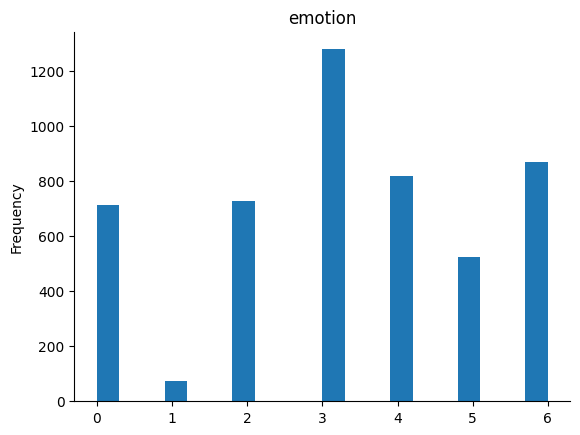

In [ ]:
#checking amount of data per class
from matplotlib import pyplot as plt
train_df['emotion'].plot(kind='hist', bins=20, title='emotion')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
x=train_df['pixels']
y=train_df['emotion']

In [ ]:
#converting to numpy
y=y.to_numpy()

X=x.to_numpy()
for i in range(len(X)):
  X[i] = np.array(X[i].split(), dtype=np.uint8).reshape(48,48)

In [ ]:
X.shape

(5000,)

In [ ]:
#confirming if X is nested array
if isinstance(X[0], np.ndarray):
  print("True")

True


In [ ]:
Xx=np.array([list(i) for i in X]) #converting it into proper format for entering into model

# Data_preprocessing for pre-trained models

In [ ]:
#since given b&w image, convert to 3 channel by repeating
def expand_greyscale_image_channels(grey_image_arr):
    grey_image_arr = np.expand_dims(grey_image_arr, -1)
    grey_image_arr_3_channel = grey_image_arr.repeat(3, axis=-1)
    return grey_image_arr_3_channel

XX=expand_greyscale_image_channels(Xx)

In [ ]:
#performing stratified shuffle split
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.1)
for train_index, valid_index in split.split(XX, y):
    X_train, X_valid = XX[train_index], XX[valid_index]
    y_train, y_valid = y[train_index], y[valid_index]


In [ ]:
# creating tensor prefetch datasets which are easier to enter into models
train_dataset1 = tf.data.Dataset.from_tensor_slices((X_train, y_train))
valid_dataset1 = tf.data.Dataset.from_tensor_slices((X_valid, y_valid))

In [ ]:
batch_size = 48

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(factor=0.2, seed=42),  # Rotate up to ±10 degrees
    tf.keras.layers.RandomBrightness(factor=0.2, seed=42),  # Change brightness
    tf.keras.layers.RandomFlip(mode="horizontal", seed=42),  # Flip horizontally
    tf.keras.layers.RandomZoom(height_factor=0.2, width_factor=0.2, seed=42)  # Zoom
])
#performing data augmentation

# **vgg19**

similar to vgg16 model structure and training implemented

In [ ]:
#creating a preprocess layer for every model
preprocess2 = tf.keras.Sequential([
    tf.keras.layers.Resizing(height=224, width=224, crop_to_aspect_ratio=True),
    tf.keras.layers.Lambda(tf.keras.applications.vgg19.preprocess_input)])

In [ ]:
train_dataset1 = train_dataset1.map(lambda X, y: (data_augmentation(X), y))
train_set2 = train_dataset1.map(lambda X, y: (preprocess2(X), y))
train_set2 = train_set2.shuffle(1000, seed=42).batch(batch_size).prefetch(1)
valid_set2 = valid_dataset1.map(lambda X, y: (preprocess2(X), y)).batch(batch_size)

In [ ]:
#getting our base pretrained model and creating our model using weights as imagenet
base_model2 = tf.keras.applications.vgg19.VGG19(weights="imagenet",include_top=False)# not including top layers as they use different classes
avg = tf.keras.layers.GlobalAveragePooling2D()(base_model2.output)
x=tf.keras.layers.Dropout(0.5)(avg)#Added to prevent overfitting
output = tf.keras.layers.Dense(7, activation="softmax")(x)
model2 = tf.keras.Model(inputs=base_model2.input, outputs=output)

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
#freezing all the layers in pre-trained model
for layer in base_model2.layers:
  layer.trainable = False

In [ ]:
#compliling and fitting our model to data
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001,momentum=0.9,nesterov=True)
model2.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,metrics=["accuracy"])
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_accuracy', factor=0.75, patience=5, min_lr=0.000001)
history = model2.fit(train_set2, validation_data=valid_set2, epochs=20, callbacks=[reduce_lr])

Epoch 1/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 79s 553ms/step - accuracy: 0.2027 - loss: 4.5404 - val_accuracy: 0.3280 - val_loss: 1.8755 - learning_rate: 0.0010
Epoch 2/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 36s 288ms/step - accuracy: 0.2674 - loss: 2.6815 - val_accuracy: 0.3500 - val_loss: 1.7799 - learning_rate: 0.0010
Epoch 3/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 29s 294ms/step - accuracy: 0.2911 - loss: 2.2673 - val_accuracy: 0.3700 - val_loss: 1.6919 - learning_rate: 0.0010
Epoch 4/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 40s 283ms/step - accuracy: 0.3303 - loss: 2.0724 - val_accuracy: 0.3880 - val_loss: 1.6613 - learning_rate: 0.0010
Epoch 5/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 42s 297ms/step - accuracy: 0.3383 - loss: 1.9799 - val_accuracy: 0.4480 - val_loss: 1.6118 - learning_rate: 0.0010
Epoch 6/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 40s 285ms/step - accuracy: 0.3391 - loss: 1.9366 - val_accuracy: 0.3800 - val_loss: 1.6465 - learning_rate: 0.0010
Epoch 7/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 44s 321ms/step - accuracy: 0.3451 - loss: 1.

In [ ]:
# The VGG16 model has 19 layers. The range should be (0,18)
for i in range(len(base_model2.layers)):
    print(f"{i:3}: {base_model2.layers[i].name:22}")

  0: input_layer_1         
  1: block1_conv1          
  2: block1_conv2          
  3: block1_pool           
  4: block2_conv1          
  5: block2_conv2          
  6: block2_pool           
  7: block3_conv1          
  8: block3_conv2          
  9: block3_conv3          
 10: block3_conv4          
 11: block3_pool           
 12: block4_conv1          
 13: block4_conv2          
 14: block4_conv3          
 15: block4_conv4          
 16: block4_pool           
 17: block5_conv1          
 18: block5_conv2          
 19: block5_conv3          
 20: block5_conv4          
 21: block5_pool           


=> model has very little data even after augmentation

=> unfreeze very few layers(1 or 2) as number layers is also very little

In [ ]:
#unfreezing very few layers
for layer in base_model2.layers[20:]:
  layer.trainable = True

In [ ]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.0001, momentum=0.9,nesterov=True)
model2.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,metrics=["accuracy"])
#reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_accuracy', factor=0.75, patience=4, min_lr=0.000001)
history = model2.fit(train_set2, validation_data=valid_set2, epochs=40)# callbacks=[reduce_lr] can be used

Epoch 1/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 40s 350ms/step - accuracy: 0.3879 - loss: 1.6408 - val_accuracy: 0.4620 - val_loss: 1.4500
Epoch 2/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 31s 288ms/step - accuracy: 0.4546 - loss: 1.4596 - val_accuracy: 0.4740 - val_loss: 1.3930
Epoch 3/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 29s 287ms/step - accuracy: 0.4734 - loss: 1.3793 - val_accuracy: 0.4840 - val_loss: 1.3738
Epoch 4/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 42s 287ms/step - accuracy: 0.5010 - loss: 1.3364 - val_accuracy: 0.4980 - val_loss: 1.3349
Epoch 5/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 41s 287ms/step - accuracy: 0.5307 - loss: 1.2933 - val_accuracy: 0.5060 - val_loss: 1.3265
Epoch 6/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 28s 286ms/step - accuracy: 0.5376 - loss: 1.2639 - val_accuracy: 0.5220 - val_loss: 1.3064
Epoch 7/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 41s 284ms/step - accuracy: 0.5521 - loss: 1.2064 - val_accuracy: 0.5280 - val_loss: 1.2929
Epoch 8/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 41s 287ms/step - accuracy: 0.5573 - loss: 1.1952 - val_accu

11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 207ms/step


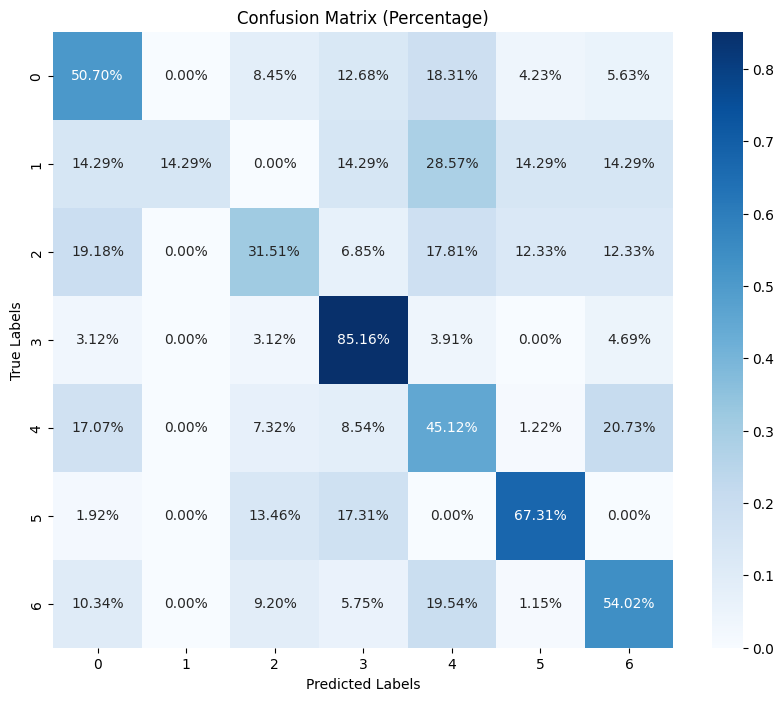

In [ ]:
#predicting on the validation set
y_pred = model2.predict(valid_set2)
y_pred_classes = np.argmax(y_pred, axis=1)
#creating confusion matrix to analyze prediction
cm = confusion_matrix(y_valid, y_pred_classes)

# Normalize for %
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Blues", xticklabels=np.arange(7), yticklabels=np.arange(7))
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix (Percentage)")
plt.show()

16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 251ms/step
Validation Accuracy per Class:
Class 0: 0.1788
Class 1: 0.0000
Class 2: 0.2162
Class 3: 0.2857
Class 4: 0.2000
Class 5: 0.2368
Class 6: 0.2000


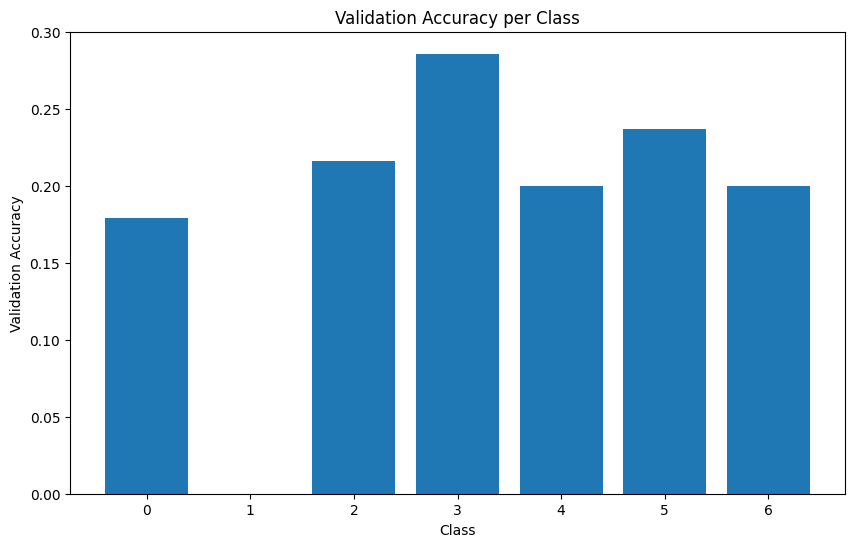

In [ ]:
#classification report to check accuracies
report = classification_report(y_valid, y_pred, output_dict=True)

# validation accuracy for each class
class_accuracies = [report[label]['precision'] for label in report if label.isdigit()] #create a list of precision values from the report dictionary

print("Validation Accuracy per Class:")
for i, acc in enumerate(class_accuracies):
  print(f"Class {i}: {acc:.4f}")

plt.figure(figsize=(10, 6))
plt.bar(range(len(class_accuracies)), class_accuracies)
plt.xlabel("Class")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy per Class")
plt.xticks(range(len(class_accuracies)))
plt.show()

In [ ]:
# save the above model
model2.save('vgg19ex.keras')